* * *
<pre> NYU            <i> Machine Learning </i></pre>
* * *


<h1 align="center"> Lab: Dimension Reduction </h1>

<pre align="left"> June 8th 2026               <i> Author: Guillaume Staerman </i></pre>
* * *


##### Goals:
- Understand PCA deeply and see when it can be useful or not
- Evaluate other dimension reduction methods

In [1]:
import numpy as np
from matplotlib import pyplot as plt

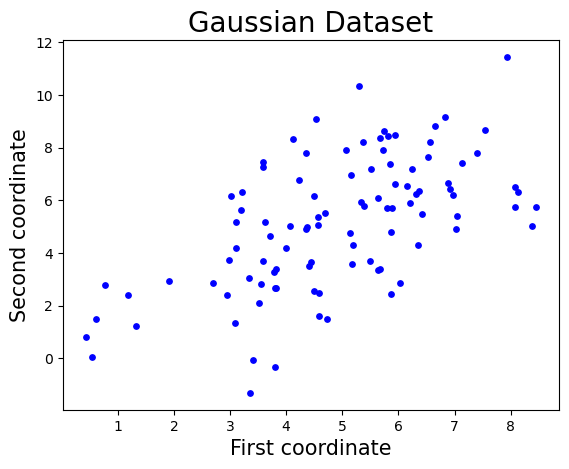

In [2]:
# Sample one dataset with (correlated) Gaussian distribution
np.random.seed(0)

# Size of data
n_samples = 100
n_dim = 2

# Mean vector of the dataset
mean = 5 *  np.ones(n_dim)

# Sample covariance matrix from a Wishart distribution
temp = np.random.randn(n_dim, n_dim)
cov = temp@temp.T

X = np.random.multivariate_normal(mean, cov, size=n_samples)

plt.scatter(X[:, 0], X[:, 1], s=15, c='b')
plt.xlabel('First coordinate', size=15)
plt.ylabel('Second coordinate', size=15)
plt.title('Gaussian Dataset', size=20)
plt.show()

### Question 1:

Implement your own PCA algorithm.

In [3]:
class MyPCA(object):

    def __init__(self, n_components):
        self.n_components = n_components


    def fit(self, X):
        # PCA works on centered data, so we store the training mean
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Covariance matrix of the (centered) features
        cov_matrix = np.cov(X_centered, rowvar=False)

        # The covariance matrix is symmetric -> use eigh (real eigenvalues/vectors)
        eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

        # sort the eigenvalues in descending order
        sorted_index = np.argsort(eigen_values)[::-1]

        self.eigenvalues = eigen_values[sorted_index]

        # similarly sort the eigenvectors (they are stored as columns)
        self.eigenvectors = eigen_vectors[:, sorted_index]
        self.eigenvector_subset = self.eigenvectors[:, :self.n_components]


    def transform(self, Z):
        # Center the input with the training mean, then project onto the components
        return (Z - self.mean) @ self.eigenvector_subset

### Question 2

Apply PCA on the Gaussian dataset

In [4]:
# Fit our PCA on the Gaussian dataset and project it
pca = MyPCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)

print("Eigenvalues (variance carried by each component):", pca.eigenvalues)
print("Transformed data shape:", X_pca.shape)

Eigenvalues (variance carried by each component): [7.78619202 1.67113936]
Transformed data shape: (100, 2)


### Question 3

Verify that your transformed data are decorrelated. What do you observe?

In [5]:
# If the data are decorrelated, the covariance matrix of the transformed data
# must be diagonal (off-diagonal entries ~ 0)
cov_transformed = np.cov(X_pca, rowvar=False)
print("Covariance matrix of the transformed data:\n", np.round(cov_transformed, 6))

Covariance matrix of the transformed data:
 [[7.786192 0.      ]
 [0.       1.671139]]


**Observation:** The covariance matrix of the transformed data is diagonal with every off-diagonal entry basically 0. This proves hat the principal components are uncorrelated. PCA rotates the data onto the eigenvectors of the covariance matrix, which diagonalizes it. The diagonal entries are the eigenvalues (the variance by each component), listed in decreasing.

### Question 4

Visualize your transformed data after PCA.

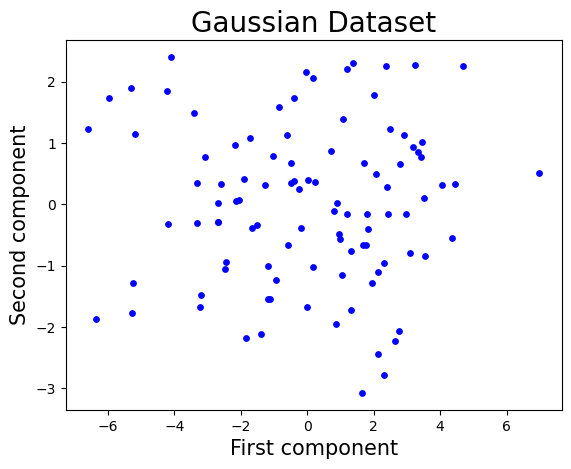

In [6]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=15, c='b')
plt.xlabel('First component', size=15)
plt.ylabel('Second component', size=15)
plt.title('Gaussian Dataset', size=20)
plt.show()

### Question 5

Compare your algorithm with the one in sklearn. You can check the covariance matrix of the transformed data. Is this the same than yours? What do you observe?

In [7]:
from sklearn.decomposition import PCA

In [8]:
sk_pca = PCA(n_components=2)
X_sk = sk_pca.fit_transform(X)

print("MyPCA covariance of transformed data:\n", np.round(np.cov(X_pca, rowvar=False), 4))
print("\nsklearn covariance of transformed data:\n", np.round(np.cov(X_sk, rowvar=False), 4))

# Principal components are only defined up to a sign, so we compare the
# projections in absolute value.
print("\nMax abs difference between the two projections (up to sign):",
      np.abs(np.abs(X_pca) - np.abs(X_sk)).max())

MyPCA covariance of transformed data:
 [[7.7862 0.    ]
 [0.     1.6711]]

sklearn covariance of transformed data:
 [[7.7862 0.    ]
 [0.     1.6711]]

Max abs difference between the two projections (up to sign): 1.4876988529977098e-14


**Observation:** The two covariance matrices of the transformed data are identical (diagonal, with the same eigenvalues on the diagonal). The projections  match up to a sign flip on each component — eigenvectors are only defined up to sign (absolute), so a given axis may actually point in the opposite direction. Apart from that sign ambiguity, the hand-written PCA produces same result as scikit-learn implementation.

### Bonus Question

Compare the computational time of both algorithms, what do you observe? Why?

In [9]:
import time

In [10]:
n_runs = 200

start = time.time()
for _ in range(n_runs):
    p = MyPCA(n_components=2)
    p.fit(X)
    p.transform(X)
my_time = (time.time() - start) / n_runs

start = time.time()
for _ in range(n_runs):
    p = PCA(n_components=2)
    p.fit_transform(X)
sk_time = (time.time() - start) / n_runs

print(f"MyPCA   : {my_time * 1e3:.4f} ms / run")
print(f"sklearn : {sk_time * 1e3:.4f} ms / run")

MyPCA   : 0.0632 ms / run
sklearn : 0.1731 ms / run


**Observation:** My `MyPCA` is *faster* than scikit-learn's `PCA`, probably because of overhead: `MyPCA` does a single `np.cov` + `eigh` call, whereas sklearn's `PCA` wraps a full SVD with input validation, solver selection, mean/variance bookkeeping, and object setup. For such a small problem that change allows MyPCA to dominate. For large, high-dim data the picture is opposite: sklearn's SVD-based solver (and `svd_solver='randomized'`) is more efficient and numerically stable than forming full covariance matrix and eigendecomposing it, which costs O(d²·n + d³).

### Question 6

Let's apply the PCA on a (easy) classification real-world dataset. Apply PCA with 2 components and visualize the dataset with different colors for each class.

In [11]:
from sklearn import datasets

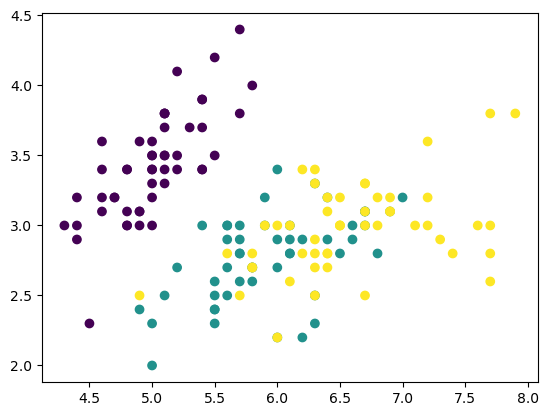

In [12]:
iris = datasets.load_iris()

X_iris = iris.data
y_iris = iris.target

plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris)
plt.show()

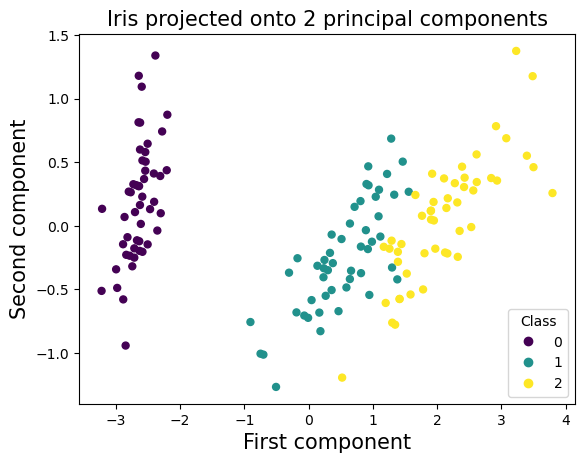

Explained variance ratio: [0.92461872 0.05306648]
Total variance kept with 2 components: 0.977685206318798


In [13]:
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris)

scatter = plt.scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=y_iris, cmap='viridis', s=25)
plt.xlabel('First component', size=15)
plt.ylabel('Second component', size=15)
plt.title('Iris projected onto 2 principal components', size=15)
plt.legend(*scatter.legend_elements(), title="Class")
plt.show()

print("Explained variance ratio:", pca_iris.explained_variance_ratio_)
print("Total variance kept with 2 components:", pca_iris.explained_variance_ratio_.sum())

### Question 7

Use a KNN algorithm and perform it on the dataset. Use different combinations of parameters using the GridSearchCV function.

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=0, stratify=y_iris)

param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],  # 1 = Manhattan, 2 = Euclidean
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score  :", round(grid.best_score_, 4))
print("Test accuracy  :", round(grid.score(X_test, y_test), 4))

Best parameters: {'n_neighbors': 7, 'p': 2, 'weights': 'distance'}
Best CV score  : 0.9429
Test accuracy  : 1.0


### Question 8

Use a PCA first and then apply again the classification algorithm. Observe the best score, is the PCA improve the results? Which explanation can you give?

In [16]:
# Reduce to 2 components first (fit on train, apply to test), then run the same grid search
pca2 = PCA(n_components=2)
X_train_pca = pca2.fit_transform(X_train)
X_test_pca = pca2.transform(X_test)

grid_pca = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_pca.fit(X_train_pca, y_train)

print("Best parameters (PCA):", grid_pca.best_params_)
print("Best CV score   (PCA):", round(grid_pca.best_score_, 4))
print("Test accuracy   (PCA):", round(grid_pca.score(X_test_pca, y_test), 4))

Best parameters (PCA): {'n_neighbors': 1, 'p': 2, 'weights': 'uniform'}
Best CV score   (PCA): 0.9524
Test accuracy   (PCA): 0.9556


**Observation:** Reducing Iris from 4 to 2 dims before KNN gives a comparable result, but doesn't improve classification. The cross-validated score is about the same (PCA's CV is even marginally higher) while the held-out test accuracy is slightly lower than full-feature model. Iris is already low-dim, the 4 features aren't redundant, and KNN should be fine in 4-D. The first two principal components already capture ~98% of the variance, so dropping the last two loses little class-discriminative information but also offers nothing to gain. PCA mainly improves classification when the original space is high-dim and noisy/redundant (curse of dimensionality), which isn't case for a clean 4-feature dataset.

### Question 9

How features influence the first components (in term of variance)? You can answer this question by inspecting the weights in the first component.

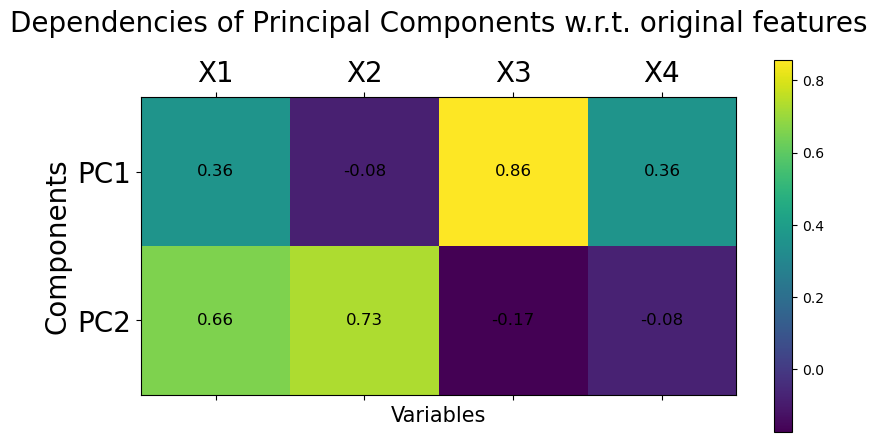

In [17]:
# Fit a 2-component PCA on the full iris data so we can inspect the loadings
pca = PCA(n_components=2).fit(X_iris)

plt.matshow(pca.components_)
plt.ylabel('Components', size=20)
plt.xlabel('Variables', size=15)
for i in range(4):
    for j in range(2):
        plt.text(i, j, "%0.2f" % pca.components_[j, i], size=12, color='black', ha="center", va="center")
plt.colorbar()
xlabels = ['X1', 'X2', 'X3', 'X4']
plt.xticks(range(4), xlabels, size=20)
ylabels = ['PC1', 'PC2']
plt.yticks(range(2), ylabels, size=20)
plt.title('Dependencies of Principal Components w.r.t. original features', size=20, pad=20)
plt.show()

**Observation:** Each principal component is weighted combination of the four original fts, and the weights give info about how much each var contributes. PC1 is dominated by petal length (X3) and petal width (X4). Such large-magnitude weights mean PC1 essentially measures overall petal size, the direction of greatest variance and the one that best separates the species. PC2 is driven mostly by sepal width (X2). Because Iris features are on different scales, standardizing before PCA would change these weights; the raw-data PCA here reflects the features' natural variances.

### Bonus Question

Create a pipeline with KNN, classification trees, RandomForest and SVM. Perform the Question 7/8 for these 4 classifiers. What do you observe?

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# (estimator, grid). Parameters are prefixed 'clf__' to target the classifier step.
classifiers = {
    'KNN':          (KNeighborsClassifier(),                  {'clf__n_neighbors': [3, 5, 7], 'clf__weights': ['uniform', 'distance']}),
    'DecisionTree': (DecisionTreeClassifier(random_state=0),  {'clf__max_depth': [2, 3, 5, None]}),
    'RandomForest': (RandomForestClassifier(random_state=0),  {'clf__n_estimators': [50, 100], 'clf__max_depth': [2, 3, None]}),
    'SVM':          (SVC(),                                   {'clf__C': [0.1, 1, 10], 'clf__kernel': ['linear', 'rbf']}),
}

print(f"{'Classifier':13s} | {'raw acc':>8s} | {'PCA(2) acc':>10s}")
print("-" * 40)
for name, (clf, grid_params) in classifiers.items():
    # Without PCA
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    gs = GridSearchCV(pipe, grid_params, cv=5).fit(X_train, y_train)
    score_raw = gs.score(X_test, y_test)

    # With PCA (2 components)
    pipe_pca = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2)), ('clf', clf)])
    gs_pca = GridSearchCV(pipe_pca, grid_params, cv=5).fit(X_train, y_train)
    score_pca = gs_pca.score(X_test, y_test)

    print(f"{name:13s} | {score_raw:8.3f} | {score_pca:10.3f}")

Classifier    |  raw acc | PCA(2) acc
----------------------------------------
KNN           |    0.978 |      0.933
DecisionTree  |    0.956 |      0.911
RandomForest  |    0.956 |      0.844
SVM           |    1.000 |      0.911


**Observation:** All four classifiers reach high accuracy on Iris using the full features (KNN/SVM ~0.98–1.0). Putting PCA down to 2 components keeps accuracy reasonable but also pretty low (RandomForest drops most), so PCA brings no improvement herem, mainly b/c the data is small and low-dim with little redundancy to start. Everything's wrapped in a `Pipeline` because the scaler and PCA are fit only on the training folds inside cross-valid, avoiding info leakage from test set. On a genuinely high-dim data, PCA would help for distance-based methods like KNN or SVM than for trees.

### Question 10

Time to apply PCA on a high dimensional dataset.

In [19]:
from sklearn.datasets import load_digits
digits = load_digits()
X_d = digits.data
y_d = digits.target

print(X_d.shape)

(1797, 64)


### Question 11

Now, you will have to reduce the dimension. The main question is: how to choose the number of components? Propose a method to determine a relevant number of components to keep.

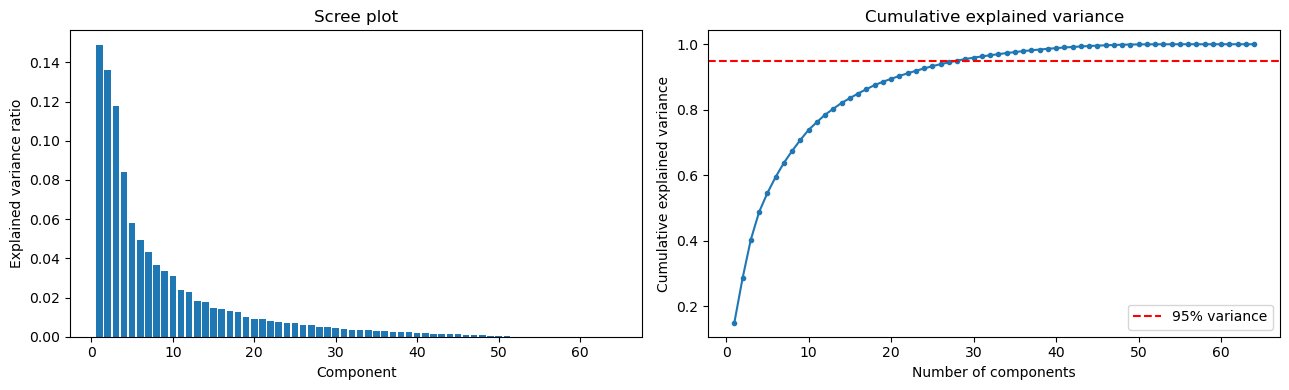

Components needed for 90% of variance: 21
Components needed for 95% of variance: 29


In [20]:
# A common method: fit PCA with all components and look at the cumulative
# explained variance. We keep the smallest number of components that retains
# a chosen fraction of the total variance (e.g. 95%). The "elbow" of the
# scree curve is another visual criterion.
pca_full = PCA().fit(X_d)
explained = pca_full.explained_variance_ratio_
cum = np.cumsum(explained)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(np.arange(1, len(explained) + 1), explained)
ax1.set_xlabel('Component')
ax1.set_ylabel('Explained variance ratio')
ax1.set_title('Scree plot')

ax2.plot(np.arange(1, len(cum) + 1), cum, marker='.')
ax2.axhline(0.95, color='r', linestyle='--', label='95% variance')
ax2.set_xlabel('Number of components')
ax2.set_ylabel('Cumulative explained variance')
ax2.set_title('Cumulative explained variance')
ax2.legend()
plt.tight_layout()
plt.show()

n_95 = int(np.argmax(cum >= 0.95) + 1)
n_90 = int(np.argmax(cum >= 0.90) + 1)
print(f"Components needed for 90% of variance: {n_90}")
print(f"Components needed for 95% of variance: {n_95}")

**Method:** To choose number of kept-components we could plot the cumulative explained-variance curve and keep the smallest number of components that reaches a target threshold of the total variance (90–95%). On the digits data, abt **~21 components retain 90%** and **~29 retain 95%** of the variance, much less than original 64 fts. Scree plot shows variance/component dropping off quik. In scikit-learn this could be done with `PCA(n_components=0.95)`, which auto-selects number of components.

### Question 12

Run PCA on the handwritten digits data reducing its dimension from 64 to 2. Visualise digits in dimension two. Is dimension two seems enough to represent keep information of data?

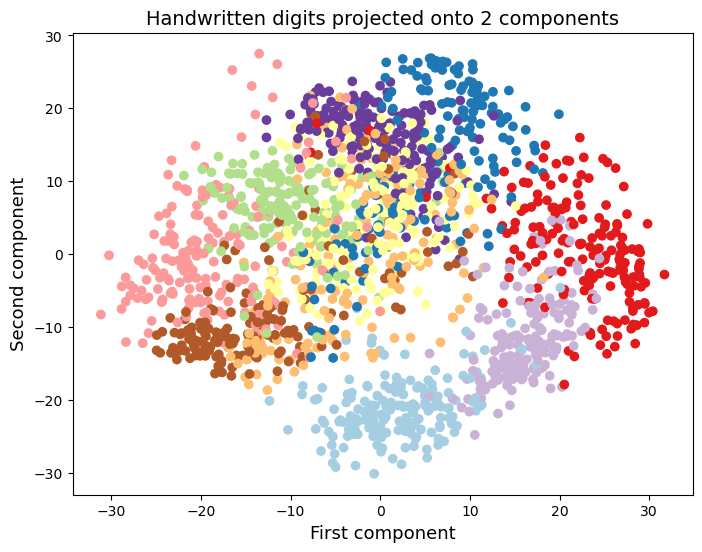

In [21]:
from matplotlib import cm

vis = PCA(n_components=2).fit_transform(X_d)
colors = cm.Paired(np.linspace(0., 1., 10)) # list of 10 colors

colors_all = colors[digits.target]
plt.figure(figsize=(8, 6))
plt.scatter(vis[:, 0], vis[:, 1], c=colors_all)
plt.xlabel('First component', size=13)
plt.ylabel('Second component', size=13)
plt.title('Handwritten digits projected onto 2 components', size=14)
plt.show()

**Observation:** Two dimensions aren't enough to fully rep the digits. The 2-component projection keeps only a small fraction of the total variance (~22%), so while some digit clusters (0, 4, 6) separate well, many others overlap heavily in a tangled blob. The classes are not cleanly separable in 2-D. A linear projection onto two axes can't preserve the rich structure of 64-dim images. To retain most of the info we need more components (~30 for 95% variance); non-linear methods like t-SNE would prob give much cleaner 2-D separation for visualization.

### Question 13

Perform a KNN algorithm on the raw data and on the projected data. What do you observe in terms of accuracy?

In [22]:
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_d, y_d, test_size=0.3, random_state=0, stratify=y_d)

# 1) Raw data (64 dimensions)
knn_raw = KNeighborsClassifier(n_neighbors=5).fit(Xd_train, yd_train)
acc_raw = knn_raw.score(Xd_test, yd_test)

# 2) Projected onto 2 components
pca_2d = PCA(n_components=2).fit(Xd_train)
knn_2d = KNeighborsClassifier(n_neighbors=5).fit(pca_2d.transform(Xd_train), yd_train)
acc_2d = knn_2d.score(pca_2d.transform(Xd_test), yd_test)

# 3) Projected keeping 95% of the variance
pca_95 = PCA(n_components=0.95).fit(Xd_train)
knn_95 = KNeighborsClassifier(n_neighbors=5).fit(pca_95.transform(Xd_train), yd_train)
acc_95 = knn_95.score(pca_95.transform(Xd_test), yd_test)

print(f"Raw data (64 dim)         accuracy: {acc_raw:.3f}")
print(f"PCA -> 2 dim              accuracy: {acc_2d:.3f}")
print(f"PCA -> 95% variance ({pca_95.n_components_:2d} dim) accuracy: {acc_95:.3f}")

Raw data (64 dim)         accuracy: 0.980
PCA -> 2 dim              accuracy: 0.606
PCA -> 95% variance (28 dim) accuracy: 0.980


**Observation:** KNN on the raw 64-D data is already very accurate (~98%). Projecting to just 2-dims reduces accuracy b/c most of the discriminative info is lost, which is consistent with the overlapping clusters from question 12. However, projecting onto enough components to keep **95% of the variance (~29 dims)** recovers the main raw accuracy while halving the dimensionality. So PCA ended up being useful for compression and denoising the KNN. The PCA speeds up any dist. computations and mitigates curse of dimensionality, but only if enough components are kept. Reducing too aggressively (to 2) destroys class structure.

### Bonus Question

Apply other reduction dimension methods (not seen in class) such as Kernel PCA (choose one kernel), Independant Component Analysis (ICA) and t-SNE. Visualize their projection in dimension two.

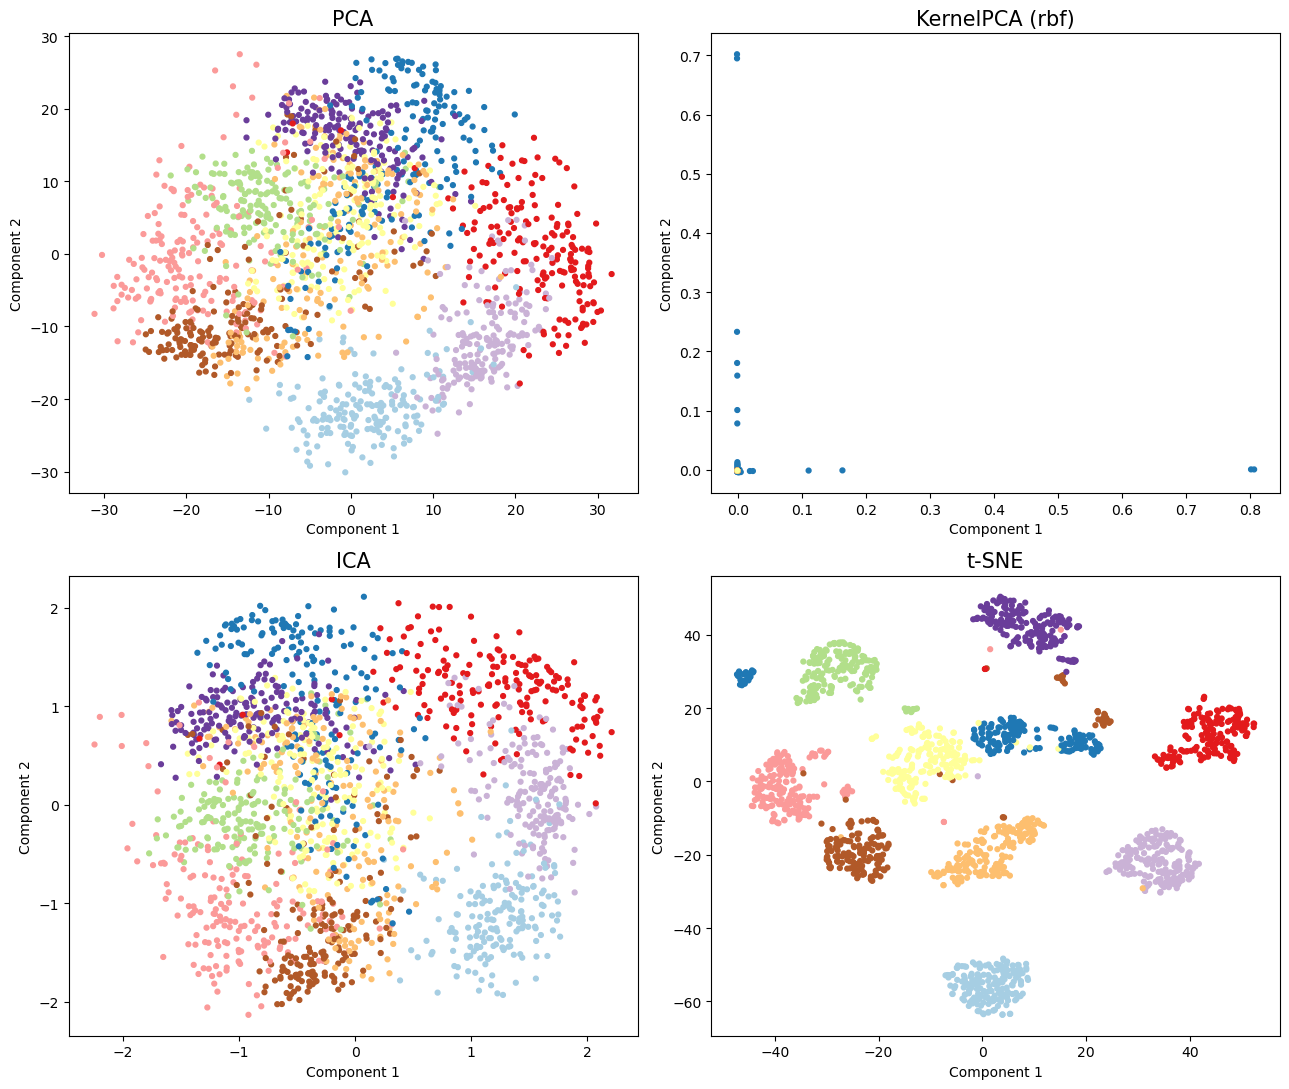

In [23]:
from sklearn.decomposition import FastICA, PCA, KernelPCA
from sklearn.manifold import TSNE

methods = {
    'PCA':              PCA(n_components=2),
    'KernelPCA (rbf)':  KernelPCA(n_components=2, kernel='rbf', gamma=0.04),
    'ICA':              FastICA(n_components=2, random_state=0),
    't-SNE':            TSNE(n_components=2, random_state=0, init='pca'),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (name, method) in zip(axes.ravel(), methods.items()):
    proj = method.fit_transform(X_d)
    ax.scatter(proj[:, 0], proj[:, 1], c=colors_all, s=12)
    ax.set_title(name, size=15)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
plt.tight_layout()
plt.show()